# Battery electrolyte property predictor — weekend one

Predicts **ionization potential (IP)** of small organic molecules directly from molecular structure (SMILES), using the same pipeline shape as [chemical-property-predictor](https://github.com/GiantWizard/chemical-property-predictor): RDKit 2D descriptors + Morgan fingerprints -> VarianceThreshold + StandardScaler -> CatBoost tuned with Optuna, 70/15/15 train/val/test split.

**Dataset:** QM9-IPEA subset of SolQuest (Weinreich et al., arXiv:2411.00994; Zenodo [10.5281/zenodo.13952172](https://doi.org/10.5281/zenodo.13952172), file `QM9IPEA.json`) — ~7,000 QM9 molecules with coupled-cluster-level ionization potentials and electron affinities. This pass uses IP only; electron affinity and multi-solvent solvation energy are growth-path items, not weekend-one scope.

See `RESULTS.md` in this project for the full writeup.

## Phase 0 — Extract SMILES + IP from the raw QM9-IPEA JSON

The raw JSON ships 3D geometry (`SYMBOLS`/`COORDS`) and per-charge-state coupled-cluster energies, but **no SMILES strings**. We recover SMILES from the neutral-molecule geometry using RDKit's bond-perception algorithm (`rdDetermineBonds`), following the shape-inspection approach in the dataset's own example script `VienUppDa/QM9IPEA/scripts/json_creation/check_json_shape.py`.

Vertical IP is defined per the paper's data-availability text as the energy difference between the neutral (charge 0) and cationic (charge +1) species at the neutral geometry, using the highest available level of theory: `PNO-LCCSD(T)-F12B` (closed shell) / `PNO-UCCSD(T)-F12B` (open shell).

In [1]:
import json
import time

import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdDetermineBonds

HARTREE_TO_EV = 27.211386245988
NEUTRAL_LEVEL = "PNO-LCCSD(T)-F12B"
CHARGED_LEVEL = "PNO-UCCSD(T)-F12B"


def xyz_block(symbols, coords):
    lines = [str(len(symbols)), ""]
    for s, c in zip(symbols, coords):
        lines.append(f"{s} {c[0]:.8f} {c[1]:.8f} {c[2]:.8f}")
    return "\n".join(lines)


def smiles_from_geometry(symbols, coords):
    mol = Chem.MolFromXYZBlock(xyz_block(symbols, coords))
    if mol is None:
        return None
    try:
        rdDetermineBonds.DetermineBonds(mol, charge=0)
        return Chem.MolToSmiles(mol)
    except Exception:
        return None

In [2]:
t0 = time.time()
with open("../data/QM9IPEA.json") as f:
    d = json.load(f)

n_total = len(d["QM9_ID"])
print(f"Raw QM9-IPEA entries: {n_total}")

e_neutral = d["ENERGY"]["0"][NEUTRAL_LEVEL]
e_cation = d["ENERGY"]["1"][CHARGED_LEVEL]

rows = []
n_geom_fail = 0
n_energy_missing = 0

for i in range(n_total):
    en, ec = e_neutral[i], e_cation[i]
    if en is None or ec is None or en != en or ec != ec:
        n_energy_missing += 1
        continue
    smi = smiles_from_geometry(d["SYMBOLS"][i], d["COORDS"][i])
    if smi is None:
        n_geom_fail += 1
        continue
    rows.append({
        "qm9_id": d["QM9_ID"][i],
        "smiles": smi,
        "ionization_potential_eV": (ec - en) * HARTREE_TO_EV,
    })

extraction_time = time.time() - t0
raw_ip = pd.DataFrame(rows)
print(f"Missing neutral/cation energy: {n_energy_missing}")
print(f"Geometry -> SMILES perception failures: {n_geom_fail}")
print(f"Retained: {len(raw_ip)} / {n_total}")
print(f"Extraction time: {extraction_time:.1f}s")
raw_ip.head()

Raw QM9-IPEA entries: 7000


[13:51:35] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:51:35] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:51:36] Explicit valence for atom # 3 C, 5, is greater than permitted


[13:51:36] Explicit valence for atom # 1 C, 5, is greater than permitted
[13:51:36] Explicit valence for atom # 3 C, 5, is greater than permitted


[13:51:36] Explicit valence for atom # 1 C, 5, is greater than permitted
[13:51:36] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:51:36] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:51:36] Explicit valence for atom # 2 C, 5, is greater than permitted


[13:51:36] Explicit valence for atom # 5 C, 5, is greater than permitted
[13:51:36] Explicit valence for atom # 3 C, 5, is greater than permitted
[13:51:36] Explicit valence for atom # 4 C, 5, is greater than permitted


Missing neutral/cation energy: 999
Geometry -> SMILES perception failures: 302
Retained: 5699 / 7000
Extraction time: 1.2s


,qm9_id,smiles,ionization_potential_eV
0,18,[H]C([H])([H])C(=O)C([H])([H])[H],9.866624
1,34,[H]OC([H])([H])C#N,11.919553
2,72,[H]C([H])([H])C(=O)C([H])([H])C([H])([H])[H],9.725051
3,155,[H]OC([H])([H])[C@]1([H])OC1([H])[H],10.620047
4,222,[H]C#CC(O[H])(C([H])([H])[H])C([H])([H])[H],10.322318


## Phase 1 — Feature engineering (reused from chemical-property-predictor)

Reuses the reference repo's descriptor + fingerprint code directly (cells 5–6 of `chemical_property_predictor.ipynb`). Note: despite the brief mentioning "PCA feature engineering", the actual reference notebook does **not** use PCA — it concatenates RDKit 2D descriptors with 2048-bit Morgan fingerprints, then applies `VarianceThreshold` + `StandardScaler`. We reuse that real pipeline rather than the PCA description. The Mordred 3D-conformer step from that repo's README is skipped here (it's the slowest step, ~20-30 min, and out of weekend-one scope).

In [3]:
import numpy as np
from rdkit.Chem import AllChem, DataStructs, Descriptors


def safe_descriptors(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Descriptors.CalcMolDescriptors(mol)


t0 = time.time()
properties = raw_ip.copy()
n_start = len(properties)

desc_series = properties["smiles"].apply(safe_descriptors)
valid_mask = desc_series.notna()
descriptor_list = pd.DataFrame(desc_series[valid_mask].tolist(), index=properties.index[valid_mask])
properties = properties.loc[valid_mask]
properties = pd.concat([properties, descriptor_list], axis=1)
print(f"After 2D descriptors: {properties.shape}")

fps_list, fps_indices = [], []
for index, smi in properties["smiles"].items():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    arr = np.zeros((2048,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fps_list.append(arr)
    fps_indices.append(index)

fps = pd.DataFrame(fps_list, index=fps_indices, columns=[f"fp_{i}" for i in range(2048)])
properties = properties.loc[fps_indices]
properties = pd.concat([properties, fps], axis=1)
properties = properties.loc[:, ~properties.columns.duplicated()]

featurization_time = time.time() - t0
print(f"After fingerprints: {properties.shape}")
print(f"Retained {properties.shape[0]} / {n_start} ({100*properties.shape[0]/n_start:.1f}%)")
print(f"Featurization time: {featurization_time:.1f}s")
properties.to_csv("../data/descriptors.csv", index=False)

After 2D descriptors: (5699, 220)


[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerat

[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerator
[13:52:04] DEPRECATION WARNING: please use MorganGenerat

[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerator
[13:52:05] DEPRECATION WARNING: please use MorganGenerat

After fingerprints: (5699, 2268)
Retained 5699 / 5699 (100.0%)
Featurization time: 36.8s


## Phase 2 — Training: CatBoost tuned with Optuna, 70/15/15 split

Same convention as the reference repo: `test_size=0.3`, then 15% of the remaining train split held out as validation (train ~59.5% / val ~10.5% / test 30%), IQR-based outlier removal on the target, Optuna over 15 trials minimizing validation RMSE.

In [4]:
import optuna
from catboost import CatBoostRegressor
from sklearn import set_config
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)
set_config(transform_output="pandas")

TARGET = "ionization_potential_eV"

subset = properties[properties[TARGET].notna()].copy()
Q1, Q3 = subset[TARGET].quantile([0.25, 0.75])
IQR = Q3 - Q1
subset = subset[(subset[TARGET] >= Q1 - 1.5*IQR) & (subset[TARGET] <= Q3 + 1.5*IQR)]
print(f"{TARGET}: {len(subset)} rows after IQR cleaning (from {len(properties)})")

ionization_potential_eV: 5518 rows after IQR cleaning (from 5699)


In [5]:
X = subset.drop(columns=["qm9_id", "smiles", TARGET])
X = X.apply(pd.to_numeric, errors="coerce").dropna(axis=1, how="all").dropna()
y = subset[TARGET][X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)
print(f"train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

preprocessor = Pipeline(steps=[
    ("variance", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
])
preprocessor.fit(X_train)
X_train_p = preprocessor.transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 6),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 100.0, log=True),
        "rsm": trial.suggest_float("rsm", 0.1, 1.0),
        "loss_function": "RMSE",
        "early_stopping_rounds": 100,
        "verbose": False,
    }
    m = CatBoostRegressor(**params)
    m.fit(X_train_p, y_train, eval_set=(X_val_p, y_val), use_best_model=True)
    return np.sqrt(mean_squared_error(y_val, m.predict(X_val_p)))

tune_t0 = time.time()
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15)
tune_time = time.time() - tune_t0
print(f"Best trial RMSE (val): {study.best_value:.4f}")
print(f"Optuna tuning time: {tune_time:.1f}s")

train: 3281, val: 580, test: 1656


Best trial RMSE (val): 0.2800
Optuna tuning time: 192.2s


In [6]:
best_params = study.best_params
best_params.update({"loss_function": "RMSE", "early_stopping_rounds": 100, "verbose": 200})
model = CatBoostRegressor(**best_params)
model.fit(X_train_p, y_train, eval_set=(X_val_p, y_val), use_best_model=True)

predictions = model.predict(X_test_p)
mask = y_test.abs() > 1e-8
mape = float(np.mean(np.abs((y_test[mask] - predictions[mask]) / y_test[mask])))
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"n_test = {len(y_test)}")
print(f"R2   = {r2:.4f}")
print(f"MAE  = {mae:.4f} eV")
print(f"RMSE = {rmse:.4f} eV")
print(f"MAPE = {mape:.4f}")

0:	learn: 0.6603127	test: 0.6402458	best: 0.6402458 (0)	total: 7.64ms	remaining: 22.4s


200:	learn: 0.2842679	test: 0.3355004	best: 0.3355004 (200)	total: 3.52s	remaining: 47.8s


400:	learn: 0.2215332	test: 0.3084227	best: 0.3084227 (400)	total: 5.67s	remaining: 35.8s


600:	learn: 0.1872389	test: 0.2982732	best: 0.2982732 (600)	total: 7.82s	remaining: 30.3s


800:	learn: 0.1614918	test: 0.2924410	best: 0.2924066 (799)	total: 9.86s	remaining: 26.2s


...

2000:	learn: 0.0795325	test: 0.2807508	best: 0.2806940 (1949)	total: 25.8s	remaining: 12s


2200:	learn: 0.0714990	test: 0.2805394	best: 0.2805216 (2177)	total: 27.8s	remaining: 9.19s


2400:	learn: 0.0647462	test: 0.2802101	best: 0.2802101 (2400)	total: 29.9s	remaining: 6.57s


2600:	learn: 0.0584795	test: 0.2800615	best: 0.2800565 (2599)	total: 31.8s	remaining: 4s


Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.279982065
bestIteration = 2645

Shrink model to first 2646 iterations.
n_test = 1656
R2   = 0.8235
MAE  = 0.2185 eV
RMSE = 0.2921 eV
MAPE = 0.0234


### Analysis

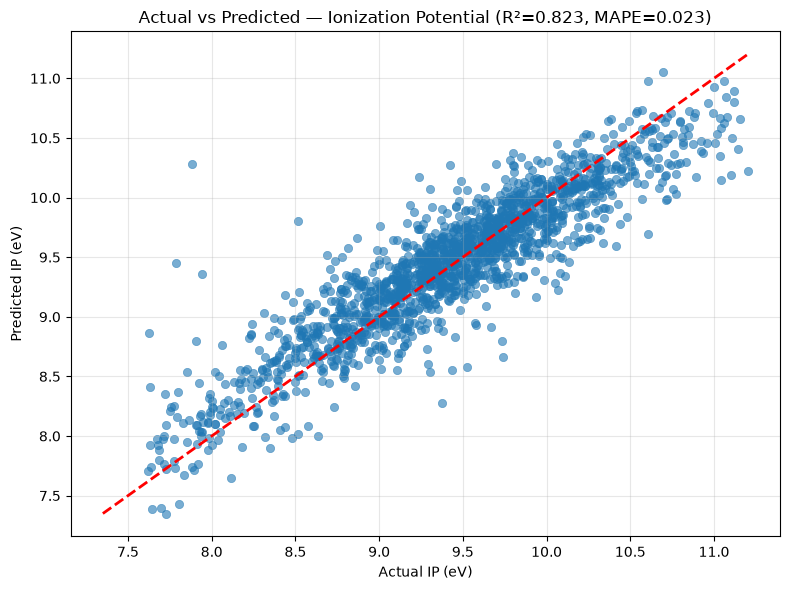

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

error_analysis = pd.DataFrame(y_test).rename(columns={TARGET: "actual"})
error_analysis["predicted"] = predictions
error_analysis["smiles"] = properties.loc[error_analysis.index, "smiles"]
error_analysis["error"] = abs(error_analysis["actual"] - error_analysis["predicted"])
error_analysis = error_analysis.sort_values(by="error", ascending=False)

plt.figure(figsize=(8, 6))
sns.scatterplot(x="actual", y="predicted", data=error_analysis, alpha=0.6, edgecolor=None)
lims = [min(error_analysis["actual"].min(), error_analysis["predicted"].min()),
        max(error_analysis["actual"].max(), error_analysis["predicted"].max())]
plt.plot(lims, lims, color="red", linestyle="--", linewidth=2)
plt.title(f"Actual vs Predicted — Ionization Potential (R²={r2:.3f}, MAPE={mape:.3f})")
plt.xlabel("Actual IP (eV)")
plt.ylabel("Predicted IP (eV)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
importances = model.get_feature_importance()
feature_names = X_train_p.columns
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False)
print("Top 20 features for ionization potential:")
print(importance_df.head(20).to_string(index=False))

Top 20 features for ionization potential:
         feature  importance
        SMR_VSA3    6.145402
        SMR_VSA7    5.464614
     VSA_EState4    3.608361
           MolMR    3.532054
      fr_aniline    3.269376
        SMR_VSA1    2.325674
     VSA_EState9    1.853602
      fr_nitrile    1.743972
     VSA_EState2    1.716022
      SlogP_VSA6    1.627036
     BCUT2D_MRHI    1.601970
    BCUT2D_MWLOW    1.590837
           Chi4v    1.534628
       PEOE_VSA8    1.456253
MinPartialCharge    1.434896
     BCUT2D_MWHI    1.366144
       PEOE_VSA4    1.357663
  MinEStateIndex    1.298828
    BCUT2D_MRLOW    1.294882
           Chi4n    1.260540
